# NB16 — Cross-Dataset Geographic Metal Annotation

**Goal:** Use lat/lon coordinates from each dataset to annotate samples/genomes with a
shared environmental metric, enabling cross-dataset comparison of metal gene density
in its geographic context.

**Analyses:**
1. **Moran's I spatial autocorrelation** — is metal gene density geographically structured?
   Computed for MGnify MAG genomes (22k, all with valid lat/lon). Stratified by biome (Soil vs Marine).
2. **Latitude gradient** — does metal gene density systematically vary with latitude?
3. **Cross-dataset annotation stub** — framework for joining external geochemical data
   (CSU soil measurements or similar) at lat/lon coordinates once available.

**Primary dataset:** `data/final_mags_geospatial_traits.csv` (n=22,356 genomes with lat/lon)

**Cross-dataset extension** (Blocks 5–6, requires external data):
- MicrobeAtlas: `data/sample_latlon_env.csv` (388k samples) + Spark OTU join
- AlphaEarth: `data/alphaearth_with_env.csv` (genome lat/lon)
- Australian Microbiome: portal lat/lon from `13_australian_microbiome_replication.ipynb`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import sparse
from sklearn.neighbors import BallTree
from pathlib import Path

DATA = Path('../data')
FIGS = Path('../figures')
FIGS.mkdir(exist_ok=True)

# ── Moran's I function ────────────────────────────────────────────────────────
def morans_i(values, lat, lon, k=15, n_perm=999, seed=42):
    """
    Compute Moran's I spatial autocorrelation statistic.
    Uses k-nearest neighbours (haversine) as spatial weights (row-normalised).

    Returns: (I, E_I, p_value, n_perm_I_above)
    """
    n = len(values)
    z = values - values.mean()

    # Build haversine k-NN weights
    coords_rad = np.radians(np.column_stack([lat, lon]))
    tree = BallTree(coords_rad, metric='haversine')
    dists, nbrs = tree.query(coords_rad, k=k + 1)  # +1 to include self

    # Build sparse row-normalised weights matrix (exclude self at position 0)
    rows = np.repeat(np.arange(n), k)
    cols = nbrs[:, 1:].ravel()
    data = np.ones(n * k) / k  # uniform weights, row-normalised
    W = sparse.csr_matrix((data, (rows, cols)), shape=(n, n))

    Wz = W.dot(z)
    I_obs = float(z @ Wz) / float(z @ z)
    E_I = -1.0 / (n - 1)

    # Permutation test
    rng = np.random.default_rng(seed)
    I_perm = np.empty(n_perm)
    for i in range(n_perm):
        zp = rng.permutation(z)
        I_perm[i] = float(zp @ W.dot(zp)) / float(zp @ zp)
    p_val = (np.sum(I_perm >= I_obs) + 1) / (n_perm + 1)

    return I_obs, E_I, p_val

print('Setup complete.')

Setup complete.


## Block 1 — Load MGnify MAG geospatial data

In [2]:
mags = pd.read_csv(DATA / 'final_mags_geospatial_traits.csv')
mags = mags.dropna(subset=['lat', 'lon'])

print(f'MGnify MAGs with coordinates: {len(mags):,}')
print(f'Columns: {list(mags.columns)}')
print()
print('Biome breakdown:')
print(mags['biome_name'].value_counts())
print()
print('Metal gene summary:')
print(mags[['n_metal_types', 'total_metal_genes']].describe().round(3))

MGnify MAGs with coordinates: 22,356
Columns: ['genome_id', 'sample_accession', 'lineage', 'biome_name', 'biome_lineage', 'length', 'gc_content', 'n_metal_types', 'total_metal_genes', 'domain', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'lat', 'lon']

Biome breakdown:
biome_name
Marine                11055
Soil                   7939
Marine Sediment        2940
Tomato Rhizosphere      257
Maize Rhizosphere       100
Barley Rhizosphere       65
Name: count, dtype: int64

Metal gene summary:
       n_metal_types  total_metal_genes
count      22356.000          22356.000
mean           0.031              0.041
std            0.186              0.333
min            0.000              0.000
25%            0.000              0.000
50%            0.000              0.000
75%            0.000              0.000
max            3.000             28.000


## Block 2 — Moran's I: all environmental MAGs

k=15 nearest neighbours (haversine), row-normalised binary weights. Significance by permutation (n=999).

Expected I under null = −1/(n−1) ≈ 0. Positive I = nearby genomes have similar metal gene density.

In [3]:
# All environmental (non-gut) MAGs
env_mags = mags[mags['biome_name'] != 'Human Gut'].copy()
print(f'Environmental MAGs (non-gut): {len(env_mags):,}')

for var, label in [('n_metal_types', 'Metal type diversity'), ('total_metal_genes', 'Total metal genes')]:
    vals = env_mags[var].values.astype(float)
    I, E_I, p = morans_i(vals, env_mags['lat'].values, env_mags['lon'].values, k=15, n_perm=999)
    print(f"\n{label}:")
    print(f"  Moran's I = {I:.4f}  (E[I] = {E_I:.5f})")
    print(f"  p-value (permutation, n=999) = {p:.4f}")

Environmental MAGs (non-gut): 22,356



Metal type diversity:
  Moran's I = 0.0561  (E[I] = -0.00004)
  p-value (permutation, n=999) = 0.0010



Total metal genes:
  Moran's I = 0.0309  (E[I] = -0.00004)
  p-value (permutation, n=999) = 0.3880


## Block 3 — Biome-stratified Moran's I

Test whether metal gene spatial autocorrelation is stronger in soil than marine environments.
If geographic metal gradients (geology, mining) drive the pattern, soil MAGs should show
stronger Moran's I than marine MAGs.

In [4]:
BIOMES = {'Soil': 'Soil', 'Marine': 'Marine', 'Marine Sediment': 'Marine Sediment'}

results = []
for biome_name, label in BIOMES.items():
    sub = mags[mags['biome_name'] == biome_name].copy()
    if len(sub) < 50:
        print(f'{biome_name}: insufficient data (n={len(sub)})')
        continue
    for var, var_label in [('n_metal_types', 'metal_type_diversity'), ('total_metal_genes', 'total_metal_genes')]:
        vals = sub[var].values.astype(float)
        I, E_I, p = morans_i(vals, sub['lat'].values, sub['lon'].values, k=min(15, len(sub)//2), n_perm=999)
        results.append({'biome': biome_name, 'variable': var_label,
                        'n': len(sub), 'morans_I': round(I, 4),
                        'E_I': round(E_I, 5), 'p_perm': round(p, 4)})
        print(f"{biome_name} | {var_label}: I={I:.4f}, E[I]={E_I:.5f}, p={p:.4f}, n={len(sub)}")

results_df = pd.DataFrame(results)
print()
print(results_df.to_string(index=False))

Soil | metal_type_diversity: I=0.0695, E[I]=-0.00013, p=0.0010, n=7939


Soil | total_metal_genes: I=0.0562, E[I]=-0.00013, p=0.0010, n=7939


Marine | metal_type_diversity: I=0.0318, E[I]=-0.00009, p=0.0050, n=11055


Marine | total_metal_genes: I=0.0255, E[I]=-0.00009, p=0.1800, n=11055
Marine Sediment | metal_type_diversity: I=0.0220, E[I]=-0.00034, p=0.7340, n=2940


Marine Sediment | total_metal_genes: I=0.0208, E[I]=-0.00034, p=0.6700, n=2940

          biome             variable     n  morans_I      E_I  p_perm
           Soil metal_type_diversity  7939    0.0695 -0.00013   0.001
           Soil    total_metal_genes  7939    0.0562 -0.00013   0.001
         Marine metal_type_diversity 11055    0.0318 -0.00009   0.005
         Marine    total_metal_genes 11055    0.0255 -0.00009   0.180
Marine Sediment metal_type_diversity  2940    0.0220 -0.00034   0.734
Marine Sediment    total_metal_genes  2940    0.0208 -0.00034   0.670


## Block 4 — Latitude gradient

Test whether metal gene density is correlated with absolute latitude (|lat|) within biomes.
Higher latitude → higher mining activity (N. hemisphere industrial belt), colder soils,
different weathering rates. Direction of gradient would be informative.

In [5]:
from scipy.stats import spearmanr

print('Spearman correlation: |latitude| ~ metal gene density')
print('-' * 60)

lat_results = []
for biome_name in ['Soil', 'Marine', 'Marine Sediment']:
    sub = mags[mags['biome_name'] == biome_name].copy()
    sub['abs_lat'] = sub['lat'].abs()
    for var in ['n_metal_types', 'total_metal_genes']:
        rho, pval = spearmanr(sub['abs_lat'], sub[var])
        lat_results.append({'biome': biome_name, 'variable': var,
                            'n': len(sub), 'rho': round(rho, 4), 'p': round(pval, 5)})
        sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns'))
        print(f'{biome_name:20s} | {var:25s}: rho={rho:+.4f}  p={pval:.4f} {sig}  n={len(sub)}')

lat_df = pd.DataFrame(lat_results)

# Repeat with raw latitude (signed) to see directionality
print()
print('Spearman correlation: signed latitude ~ metal gene density (N>0, S<0)')
print('-' * 60)
for biome_name in ['Soil', 'Marine', 'Marine Sediment']:
    sub = mags[mags['biome_name'] == biome_name].copy()
    for var in ['n_metal_types', 'total_metal_genes']:
        rho, pval = spearmanr(sub['lat'], sub[var])
        sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns'))
        print(f'{biome_name:20s} | {var:25s}: rho={rho:+.4f}  p={pval:.4f} {sig}')

Spearman correlation: |latitude| ~ metal gene density
------------------------------------------------------------
Soil                 | n_metal_types            : rho=-0.0824  p=0.0000 ***  n=7939
Soil                 | total_metal_genes        : rho=-0.0827  p=0.0000 ***  n=7939
Marine               | n_metal_types            : rho=-0.0267  p=0.0050 **  n=11055
Marine               | total_metal_genes        : rho=-0.0267  p=0.0050 **  n=11055
Marine Sediment      | n_metal_types            : rho=-0.0102  p=0.5809 ns  n=2940
Marine Sediment      | total_metal_genes        : rho=-0.0102  p=0.5818 ns  n=2940

Spearman correlation: signed latitude ~ metal gene density (N>0, S<0)
------------------------------------------------------------
Soil                 | n_metal_types            : rho=-0.0862  p=0.0000 ***
Soil                 | total_metal_genes        : rho=-0.0864  p=0.0000 ***
Marine               | n_metal_types            : rho=-0.0242  p=0.0108 *
Marine               | to

## Block 5 — Spatial map of metal gene density

World map showing per-genome metal type diversity coloured by quartile.

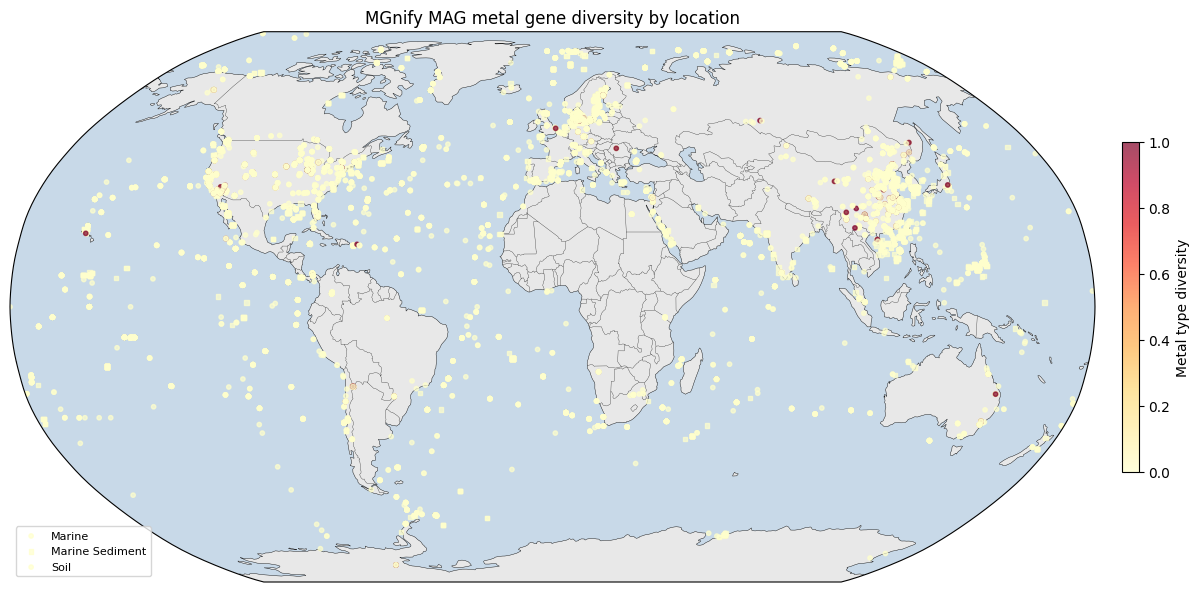

Saved: figures/nb16_mag_metal_geo_distribution.png


In [6]:
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    print('cartopy not available — using basic scatter plot')

env_plot = mags[mags['biome_name'].isin(['Soil', 'Marine', 'Marine Sediment'])].copy()

if HAS_CARTOPY:
    fig = plt.figure(figsize=(14, 6))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor='#e8e8e8', zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor='#c8d9e8', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.3, zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2, zorder=1)

    # Scatter: soil and marine separately
    for biome, color, marker, zorder in [
        ('Marine', 'steelblue', 'o', 2),
        ('Marine Sediment', 'cornflowerblue', 's', 2),
        ('Soil', 'saddlebrown', 'o', 3),
    ]:
        sub = env_plot[env_plot['biome_name'] == biome]
        sc = ax.scatter(
            sub['lon'], sub['lat'],
            c=sub['n_metal_types'], cmap='YlOrRd',
            vmin=0, vmax=sub['n_metal_types'].quantile(0.95),
            s=10, alpha=0.7, marker=marker, zorder=zorder,
            transform=ccrs.PlateCarree(),
            label=biome
        )
    plt.colorbar(sc, ax=ax, label='Metal type diversity', shrink=0.6, pad=0.02)
    ax.legend(loc='lower left', fontsize=8)
    ax.set_title('MGnify MAG metal gene diversity by location')
else:
    fig, ax = plt.subplots(figsize=(14, 7))
    for biome, color, marker in [('Marine','steelblue','o'),('Soil','saddlebrown','o')]:
        sub = env_plot[env_plot['biome_name']==biome]
        sc = ax.scatter(sub['lon'], sub['lat'], c=sub['n_metal_types'],
                       cmap='YlOrRd', s=5, alpha=0.3, marker=marker, label=biome)
    plt.colorbar(sc, ax=ax, label='Metal type diversity')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.legend()
    ax.set_title('MGnify MAG metal gene diversity by location')

plt.tight_layout()
plt.savefig(FIGS / 'nb16_mag_metal_geo_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/nb16_mag_metal_geo_distribution.png')

## Block 6 — Cross-dataset geochemical annotation

Reference datasets extracted from `arkinlab_envdbs` (Spark) and saved as CSVs:

| Source | File | n | Coverage |
|---|---|---|---|
| NGSA geochemistry | `data/ngsa_geochemistry.csv` | 1,315 | Australia (ICP-MS Cu/Zn/Pb/Ni/Co/As/Cr/Hg) |
| Mining operations | `data/mining_operations.csv` | 8,507 | Global (lat/lon, commodity) |
| CMMI ores | `data/cmmi_ores.csv` | 29,087 | Global, USA+AUS-heavy (Cu/Zn/Pb ppm) |

Three annotation layers applied to MGnify env MAGs:
1. **Mining proximity** (`dist_mine_km`) — globally applicable, all MAGs
2. **NGSA soil metals** (`ngsa_Cu_ppm`, etc.) — Australian MAGs only (max 300 km)
3. **CMMI ore metals** (`cmmi_cu_ppm`, etc.) — globally, within 200 km of an ore deposit

AusMicrobiome sample coordinates also joined to NGSA → `data/aus_microbiome/aus_sample_ngsa.csv`

In [7]:
import warnings

# ── Load reference datasets ──────────────────────────────────────────────────
ngsa  = pd.read_csv(DATA / 'ngsa_geochemistry.csv').dropna(subset=['lat','lon'])
mines = pd.read_csv(DATA / 'mining_operations.csv').dropna(subset=['latitude','longitude'])
cmmi  = pd.read_csv(DATA / 'cmmi_ores.csv').dropna(subset=['lat','lon'])

print(f'NGSA geochemistry:   {len(ngsa):>5,}  Australian soil sites')
print(f'  Cu: {ngsa["Cu_ppm"].notna().sum()}, Zn: {ngsa["Zn_ppm"].notna().sum()}, Pb: {ngsa["Pb_ppm"].notna().sum()}  ppm')
print(f'Mining operations:   {len(mines):>5,}  global mine sites')
print(f'  Top commodities: { dict(mines["primary_commodity"].value_counts().head(4)) }')
print(f'CMMI ores:           {len(cmmi):>5,}  global ore deposits')
print(f'  Valid Cu: {cmmi["cu_ppm"].notna().sum()}, Top countries: { dict(cmmi["country"].value_counts().head(3)) }')
print()


# ── Spatial join: nearest-neighbour (haversine BallTree) ────────────────────
def spatial_join_nearest(query_lat, query_lon, ref_lat, ref_lon,
                          ref_data, max_dist_km=500, prefix=''):
    """
    Assign nearest reference values to each query point within max_dist_km.
    ref_data: dict {col_name: array} with same length as ref_lat.
    Returns DataFrame (same length as query) with {prefix}dist_km + annotated columns.
    Values are NaN if no reference point within max_dist_km.
    """
    n_q = len(query_lat)
    ref_coords   = np.radians(np.column_stack([ref_lat, ref_lon]))
    query_coords = np.radians(np.column_stack([query_lat, query_lon]))
    tree = BallTree(ref_coords, metric='haversine')
    dists, idxs = tree.query(query_coords, k=1)
    dists_km = dists.ravel() * 6371.0
    idxs     = idxs.ravel()
    valid    = dists_km <= max_dist_km

    out = {f'{prefix}dist_km': dists_km}
    for col, arr in ref_data.items():
        a = np.asarray(arr, dtype=float)
        out[f'{prefix}{col}'] = np.where(valid, a[idxs], np.nan)
    matched = valid.sum()
    print(f'  [{prefix.rstrip("_")}] {matched:,}/{n_q:,} ({100*matched/n_q:.1f}%) matched within {max_dist_km} km')
    return pd.DataFrame(out)


# ── Apply annotations to MGnify env MAGs ─────────────────────────────────────
env_mags = mags[mags['biome_name'] != 'Human Gut'].copy().reset_index(drop=True)
print(f'MGnify environmental MAGs: {len(env_mags):,}')
print()

# 1. Mining proximity — all env MAGs, globally; large max so every genome gets a distance
print('Annotation 1 — mining proximity:')
mine_ann = spatial_join_nearest(
    env_mags['lat'].values, env_mags['lon'].values,
    mines['latitude'].values, mines['longitude'].values,
    ref_data={},
    max_dist_km=9000,
    prefix='mine_',
)
env_mags['dist_mine_km'] = mine_ann['mine_dist_km']
d = env_mags['dist_mine_km']
print(f'  Dist to nearest mine: p10={d.quantile(0.1):.0f} km, '
      f'med={d.median():.0f} km, p90={d.quantile(0.9):.0f} km')

# 2. NGSA Australian soil metals — max 300 km (matches NGSA spatial density ~240 km avg spacing)
print('\nAnnotation 2 — NGSA Australian soil metals:')
ngsa_ann = spatial_join_nearest(
    env_mags['lat'].values, env_mags['lon'].values,
    ngsa['lat'].values, ngsa['lon'].values,
    ref_data={k: ngsa[k].values for k in ['Cu_ppm','Zn_ppm','Pb_ppm','Ni_ppm','Co_ppm','field_pH']},
    max_dist_km=300,
    prefix='ngsa_',
)
env_mags = pd.concat([env_mags, ngsa_ann], axis=1)

# 3. CMMI ore deposit metals — max 200 km
print('\nAnnotation 3 — CMMI ore deposit metals:')
cmmi_ann = spatial_join_nearest(
    env_mags['lat'].values, env_mags['lon'].values,
    cmmi['lat'].values, cmmi['lon'].values,
    ref_data={'cu_ppm': cmmi['cu_ppm'].values, 'zn_ppm': cmmi['zn_ppm'].values,
              'pb_ppm': cmmi['pb_ppm'].values},
    max_dist_km=200,
    prefix='cmmi_',
)
env_mags = pd.concat([env_mags, cmmi_ann], axis=1)

print(f'\nAnnotated env MAGs ({len(env_mags):,} total):')
print(f'  With NGSA soil metals:   {env_mags["ngsa_Cu_ppm"].notna().sum():,}')
print(f'  With CMMI ore metals:    {env_mags["cmmi_cu_ppm"].notna().sum():,}')
print(f'  With mine distance:      {env_mags["dist_mine_km"].notna().sum():,}')

NGSA geochemistry:   1,315  Australian soil sites
  Cu: 1297, Zn: 1286, Pb: 1313  ppm
Mining operations:   8,507  global mine sites
  Top commodities: {'thermal coal': np.int64(2057), 'coal': np.int64(1237), 'copper': np.int64(901), 'metallurgical coal': np.int64(891)}
CMMI ores:           29,087  global ore deposits
  Valid Cu: 25589, Top countries: {'USA': np.int64(18561), 'AUS': np.int64(5639), 'CAN': np.int64(3412)}

MGnify environmental MAGs: 22,356

Annotation 1 — mining proximity:


  [mine] 22,356/22,356 (100.0%) matched within 9000 km
  Dist to nearest mine: p10=56 km, med=226 km, p90=838 km

Annotation 2 — NGSA Australian soil metals:
  [ngsa] 133/22,356 (0.6%) matched within 300 km

Annotation 3 — CMMI ore deposit metals:


  [cmmi] 3,033/22,356 (13.6%) matched within 200 km

Annotated env MAGs (22,356 total):
  With NGSA soil metals:   133
  With CMMI ore metals:    2,618
  With mine distance:      22,356


## Block 6b — Geochemical annotation: correlation analysis

Test whether environmental metal exposure (mining proximity, soil concentrations) predicts
metal gene density in MAGs from different biomes.

In [8]:
from scipy.stats import spearmanr

def fmt_spearman(rho, p, n):
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    return f'rho={rho:+.4f}, p={p:.3e} {sig}  (n={n})'

geo_results = []

# ── 1. Mining proximity vs metal gene density (all env MAGs) ─────────────────
print('=== Mining proximity vs metal gene density (all env MAGs) ===')
for var, label in [('n_metal_types','metal_type_diversity'), ('total_metal_genes','total_metal_genes')]:
    valid = env_mags[['dist_mine_km', var]].dropna()
    rho, p = spearmanr(valid['dist_mine_km'], valid[var])
    print(f'  dist_mine_km vs {label}:  {fmt_spearman(rho, p, len(valid))}')
    geo_results.append({'test': 'mine_proximity', 'predictor': 'dist_mine_km',
                        'response': label, 'biome': 'all_env', 'rho': rho, 'p': p, 'n': len(valid)})

# Biome-stratified mining proximity
print()
print('Mining proximity by biome:')
for biome in ['Soil', 'Marine', 'Marine Sediment']:
    sub = env_mags[env_mags['biome_name'] == biome][['dist_mine_km','n_metal_types']].dropna()
    rho, p = spearmanr(sub['dist_mine_km'], sub['n_metal_types'])
    print(f'  {biome:20s}:  {fmt_spearman(rho, p, len(sub))}')
    geo_results.append({'test': 'mine_proximity', 'predictor': 'dist_mine_km',
                        'response': 'n_metal_types', 'biome': biome, 'rho': rho, 'p': p, 'n': len(sub)})

# ── 2. NGSA soil metals vs metal genes (Australian soil MAGs only) ────────────
print()
aus_soil = env_mags[(env_mags['ngsa_Cu_ppm'].notna()) & (env_mags['biome_name'] == 'Soil')]
print(f'=== NGSA soil metals vs metal genes (Australian soil MAGs, n={len(aus_soil)}) ===')
if len(aus_soil) >= 5:
    for metal in ['ngsa_Cu_ppm', 'ngsa_Zn_ppm', 'ngsa_Pb_ppm', 'ngsa_Ni_ppm']:
        valid = aus_soil[[metal,'n_metal_types']].dropna()
        if len(valid) < 5:
            continue
        rho, p = spearmanr(valid[metal], valid['n_metal_types'])
        print(f'  {metal} vs n_metal_types:  {fmt_spearman(rho, p, len(valid))}')
        geo_results.append({'test': 'ngsa_soil', 'predictor': metal,
                            'response': 'n_metal_types', 'biome': 'Soil_AUS',
                            'rho': rho, 'p': p, 'n': len(valid)})
else:
    print('  Insufficient Australian soil MAGs in dataset for NGSA analysis.')
    print('  (MGnify MAGs from Australia are likely rare; NGSA join primarily useful for AusMicrobiome)')

# ── 3. CMMI ore metals vs metal genes (global, MAGs within 200 km of ore deposit) ──
print()
cmmi_mags = env_mags[env_mags['cmmi_cu_ppm'].notna()]
print(f'=== CMMI ore deposit metals vs metal genes (n={len(cmmi_mags)} MAGs within 200 km) ===')
if len(cmmi_mags) >= 10:
    for metal in ['cmmi_cu_ppm', 'cmmi_zn_ppm', 'cmmi_pb_ppm']:
        valid = cmmi_mags[[metal,'n_metal_types']].dropna()
        if len(valid) < 10:
            continue
        rho, p = spearmanr(valid[metal], valid['n_metal_types'])
        print(f'  {metal} vs n_metal_types:  {fmt_spearman(rho, p, len(valid))}')
        geo_results.append({'test': 'cmmi_ore', 'predictor': metal,
                            'response': 'n_metal_types', 'biome': 'all',
                            'rho': rho, 'p': p, 'n': len(valid)})
else:
    print('  Insufficient MAGs within 200 km of CMMI ore deposits.')

geo_df = pd.DataFrame(geo_results)
print()
print(geo_df[['test','predictor','biome','rho','p','n']].to_string(index=False))

=== Mining proximity vs metal gene density (all env MAGs) ===
  dist_mine_km vs metal_type_diversity:  rho=-0.0746, p=5.904e-29 ***  (n=22356)
  dist_mine_km vs total_metal_genes:  rho=-0.0744, p=7.652e-29 ***  (n=22356)

Mining proximity by biome:
  Soil                :  rho=-0.0573, p=3.199e-07 ***  (n=7939)
  Marine              :  rho=+0.0210, p=2.707e-02 *  (n=11055)
  Marine Sediment     :  rho=+0.0303, p=1.003e-01 ns  (n=2940)

=== NGSA soil metals vs metal genes (Australian soil MAGs, n=117) ===
  ngsa_Cu_ppm vs n_metal_types:  rho=+0.0300, p=7.483e-01 ns  (n=117)
  ngsa_Zn_ppm vs n_metal_types:  rho=+0.0090, p=9.234e-01 ns  (n=117)
  ngsa_Pb_ppm vs n_metal_types:  rho=+0.0424, p=6.496e-01 ns  (n=117)
  ngsa_Ni_ppm vs n_metal_types:  rho=+0.0023, p=9.806e-01 ns  (n=117)

=== CMMI ore deposit metals vs metal genes (n=2618 MAGs within 200 km) ===
  cmmi_cu_ppm vs n_metal_types:  rho=-0.0935, p=1.663e-06 ***  (n=2618)
  cmmi_zn_ppm vs n_metal_types:  rho=-0.0991, p=3.809e-07 *** 

## Block 6c — AusMicrobiome sample-level NGSA annotation

Join Australian Microbiome sample lat/lon to NGSA soil metal concentrations.
Output: `data/aus_microbiome/aus_sample_ngsa.csv` — one row per sample with
NGSA-derived Cu/Zn/Pb/Ni/Co/As and field_pH from the nearest NGSA site.

This file feeds NB13 for an NGSA-informed PGLS re-analysis to investigate
the null result (β=−0.0023, p=0.667) in the original AusMicrobiome replication.

In [9]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

AUS_DATA = DATA / 'aus_microbiome'

# Load Australian Microbiome contextual metadata with lat/lon
aus_meta = pd.read_excel(AUS_DATA / 'AM_Contextual_Data_Master_Sheet-20180501.xlsx')
aus_meta = aus_meta.dropna(subset=['latitude','longitude'])
aus_meta['latitude']  = pd.to_numeric(aus_meta['latitude'],  errors='coerce')
aus_meta['longitude'] = pd.to_numeric(aus_meta['longitude'], errors='coerce')
aus_meta = aus_meta.dropna(subset=['latitude','longitude'])

print(f'AusMicrobiome samples with lat/lon: {len(aus_meta):,}')
print(f'  Lat range: [{aus_meta["latitude"].min():.1f}, {aus_meta["latitude"].max():.1f}]')
print(f'  Lon range: [{aus_meta["longitude"].min():.1f}, {aus_meta["longitude"].max():.1f}]')
print()

# Spatial join to NGSA (max 300 km — Australia-specific, NGSA avg spacing ~240 km)
print('Joining AusMicrobiome samples to NGSA soil geochemistry:')
NGSA_METALS = ['Cu_ppm','Zn_ppm','Pb_ppm','Ni_ppm','Co_ppm','As_ppm','Cr_ppm','Hg_ppm','field_pH']
aus_ngsa = spatial_join_nearest(
    aus_meta['latitude'].values, aus_meta['longitude'].values,
    ngsa['lat'].values, ngsa['lon'].values,
    ref_data={k: ngsa[k].values for k in NGSA_METALS},
    max_dist_km=300,
    prefix='ngsa_',
)

keep_cols = ['Sample_ID','latitude','longitude']
if 'General Ecological Zone' in aus_meta.columns:
    keep_cols.append('General Ecological Zone')

aus_out = pd.concat([
    aus_meta[keep_cols].reset_index(drop=True),
    aus_ngsa
], axis=1)

aus_out.to_csv(AUS_DATA / 'aus_sample_ngsa.csv', index=False)
print(f'\nSaved: data/aus_microbiome/aus_sample_ngsa.csv  ({len(aus_out):,} rows)')
print(f'  Samples with NGSA Cu:    {aus_out["ngsa_Cu_ppm"].notna().sum():,}')
print(f'  Samples with NGSA field_pH: {aus_out["ngsa_field_pH"].notna().sum():,}')
print(f'  NGSA Cu range: [{aus_out["ngsa_Cu_ppm"].min():.1f}, {aus_out["ngsa_Cu_ppm"].max():.1f}] ppm')
print(f'  NGSA Zn range: [{aus_out["ngsa_Zn_ppm"].min():.1f}, {aus_out["ngsa_Zn_ppm"].max():.1f}] ppm')
print()
print('Next steps for NB13 NGSA-informed re-analysis:')
print('  1. Join aus_sample_ngsa.csv to OTU table (Sample_ID key)')
print('  2. Aggregate NGSA metals to genus level (mean Cu/Zn/Pb across samples where genus detected)')
print('  3. Merge with aus_levinsB_pgls_input_fixed.csv')
print('  4. Test: PGLS(levins_B_std ~ ngsa_Cu_ppm_z + ko_per_mb_total_z, tree)')

AusMicrobiome samples with lat/lon: 1,663
  Lat range: [-68.6, -10.4]
  Lon range: [78.0, 153.1]

Joining AusMicrobiome samples to NGSA soil geochemistry:
  [ngsa] 1,307/1,663 (78.6%) matched within 300 km

Saved: data/aus_microbiome/aus_sample_ngsa.csv  (1,663 rows)
  Samples with NGSA Cu:    1,293
  Samples with NGSA field_pH: 0
  NGSA Cu range: [1.1, 94.7] ppm
  NGSA Zn range: [0.9, 164.6] ppm

Next steps for NB13 NGSA-informed re-analysis:
  1. Join aus_sample_ngsa.csv to OTU table (Sample_ID key)
  2. Aggregate NGSA metals to genus level (mean Cu/Zn/Pb across samples where genus detected)
  3. Merge with aus_levinsB_pgls_input_fixed.csv
  4. Test: PGLS(levins_B_std ~ ngsa_Cu_ppm_z + ko_per_mb_total_z, tree)


## Block 7 — Save results

In [10]:
# ── Moran's I + latitude gradient (Blocks 2–4) ──────────────────────────────
results_df.to_csv(DATA / 'moran_i_metal_genes.csv', index=False)
lat_df.to_csv(DATA / 'lat_gradient_metal_genes.csv', index=False)

# ── Geochemically annotated MAGs (Block 6) ───────────────────────────────────
ann_cols = ['biome_name','lat','lon','n_metal_types','total_metal_genes',
            'dist_mine_km',
            'ngsa_dist_km','ngsa_Cu_ppm','ngsa_Zn_ppm','ngsa_Pb_ppm','ngsa_Ni_ppm','ngsa_Co_ppm','ngsa_field_pH',
            'cmmi_dist_km','cmmi_cu_ppm','cmmi_zn_ppm','cmmi_pb_ppm']
out_cols = [c for c in ann_cols if c in env_mags.columns]
env_mags[out_cols].to_csv(DATA / 'mags_annotated_geo.csv', index=False)

# ── Geochemical correlation results (Block 6b) ──────────────────────────────
geo_df.to_csv(DATA / 'geo_correlation_results.csv', index=False)

print('Saved:')
print(f'  data/moran_i_metal_genes.csv         ({len(results_df)} rows — biome-stratified Moran\'s I)')
print(f'  data/lat_gradient_metal_genes.csv    ({len(lat_df)} rows — latitude Spearman)')
print(f'  data/mags_annotated_geo.csv          ({len(env_mags):,} rows — env MAGs + NGSA/mines/CMMI)')
print(f'  data/geo_correlation_results.csv     ({len(geo_df)} rows — geochemical Spearman summary)')
print(f'  data/aus_microbiome/aus_sample_ngsa.csv  (saved in Block 6c)')
print()
print('Key geo_correlation_results:')
print(geo_df[['test','predictor','biome','rho','p','n']].to_string(index=False))

Saved:
  data/moran_i_metal_genes.csv         (6 rows — biome-stratified Moran's I)
  data/lat_gradient_metal_genes.csv    (6 rows — latitude Spearman)
  data/mags_annotated_geo.csv          (22,356 rows — env MAGs + NGSA/mines/CMMI)
  data/geo_correlation_results.csv     (12 rows — geochemical Spearman summary)
  data/aus_microbiome/aus_sample_ngsa.csv  (saved in Block 6c)

Key geo_correlation_results:
          test    predictor           biome       rho            p     n
mine_proximity dist_mine_km         all_env -0.074587 5.904361e-29 22356
mine_proximity dist_mine_km         all_env -0.074434 7.651694e-29 22356
mine_proximity dist_mine_km            Soil -0.057328 3.198657e-07  7939
mine_proximity dist_mine_km          Marine  0.021023 2.707363e-02 11055
mine_proximity dist_mine_km Marine Sediment  0.030314 1.003107e-01  2940
     ngsa_soil  ngsa_Cu_ppm        Soil_AUS  0.029976 7.483347e-01   117
     ngsa_soil  ngsa_Zn_ppm        Soil_AUS  0.008989 9.233695e-01   117
     ngsa